# CS 584 Project - Protein Function Classification with ProtBERT and MLP

#### Name: Mingji Li
#### Stevens ID: 20034303

### Install Dependencies

Install all required Python libraries for this project:

- `transformers`: Load ProtBERT model for sequence embedding
- `torch`: PyTorch deep learning framework
- `pandas`: For data manipulation
- `tqdm`: For progress bars


In [1]:
!pip install transformers torch pandas tqdm

### Load and Explore Dataset

Read the UniProt protein dataset from a `.tsv` file using `pandas`. Then review the Shape and Key columns, focusing on the `Function [CC]` field, which describes the cellular function of each protein entry.


In [2]:
import pandas as pd
import csv

df = pd.read_csv(
    "data.tsv",
    sep="\t",
    quoting=csv.QUOTE_NONE,   # Don't let quotation marks cause trouble
    dtype=str,                # Prevent pandas from guessing the wrong field type
    on_bad_lines='skip'       # no longer use error_bad_lines=False
)

print(df.shape)
print(df.columns)
print(df["Function [CC]"].dropna().head(10))

(20421, 12)
Index(['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names',
       'Organism', 'Length', 'Sequence', 'Function [CC]', 'DNA binding',
       'Gene Ontology (biological process)',
       'Gene Ontology (molecular function)'],
      dtype='object')
0    FUNCTION: May be responsible for the metabolis...
1    FUNCTION: Plays a role in regulation of the un...
2    FUNCTION: Regulates insulin sensitivity and me...
3    FUNCTION: May play an important role in innate...
4    FUNCTION: Promotes dispersal of P-body compone...
5    FUNCTION: Putative metalloproteinase that play...
6    FUNCTION: Cation/chloride cotransporter that m...
7    FUNCTION: Single-stranded RNA-binding protein ...
8    FUNCTION: Component of the intraflagellar tran...
9    FUNCTION: E3 ubiquitin-protein ligase involved...
Name: Function [CC], dtype: object


###Dataset Overview and Missing Value Analysis

Display the dataset shape, check for missing values in each column, and print out all column names.


In [3]:
print("Dataset shape (rows, columns):", df.shape)
print("\nMissing value count per column:\n", df.isnull().sum())
print("\nAll column names:\n", df.columns.tolist())

Dataset shape (rows, columns): (20421, 12)

Missing value count per column:
 Entry                                     0
Reviewed                                  0
Entry Name                                0
Protein names                             0
Gene Names                              126
Organism                                  0
Length                                    0
Sequence                                  0
Function [CC]                          3259
DNA binding                           19809
Gene Ontology (biological process)     3095
Gene Ontology (molecular function)     4255
dtype: int64

All column names:
 ['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length', 'Sequence', 'Function [CC]', 'DNA binding', 'Gene Ontology (biological process)', 'Gene Ontology (molecular function)']


> This is acceptable given the size of the dataset (over 20,000 entries).


The distribution of different prefix fragments in the protein function description (Function [CC]) field was counted

In [4]:
# Create a temporary cleaned series of function descriptions
cleaned_func_series = df["Function [CC]"].dropna().str.lower().str.replace(r'^function:\s*', '', regex=True)

# Count the number of times each function appears
func_counts = cleaned_func_series.value_counts()

print("Top 10 most frequent function descriptions:")
print(func_counts.head(10))

# Calculate the number and proportion of functions that appear only once
num_unique_funcs = (func_counts == 1).sum()
total_funcs = len(func_counts)
print(f"\n Number of unique functions that appear only once: {num_unique_funcs} , about {num_unique_funcs / total_funcs:.2%}")


Top 10 most frequent function descriptions:
Function [CC]
odorant receptor. {eco:0000305}.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

> Over 97% of function descriptions appear only once. This indicates a high degree of label sparsity, making traditional supervised classification challenging. Weak supervision or rule-based labeling will be necessary.

### Sequence Length Distribution

Visualize the distribution of protein sequence lengths in the dataset.

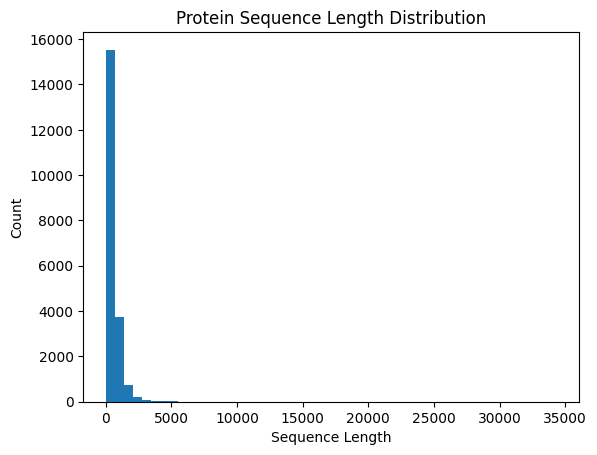

In [5]:
import matplotlib.pyplot as plt

df["seq_len"] = df["Sequence"].dropna().apply(len)
plt.hist(df["seq_len"], bins=50)
plt.title("Protein Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()


> Most protein sequences are relatively short, it's enough for most cases

### Function Keyword Word Cloud

Generate a word cloud based on the `"Function [CC]"` field to visualize the most frequently used terms in protein function descriptions.

This provides an intuitive overview of key biological activities and terminology present in the dataset.

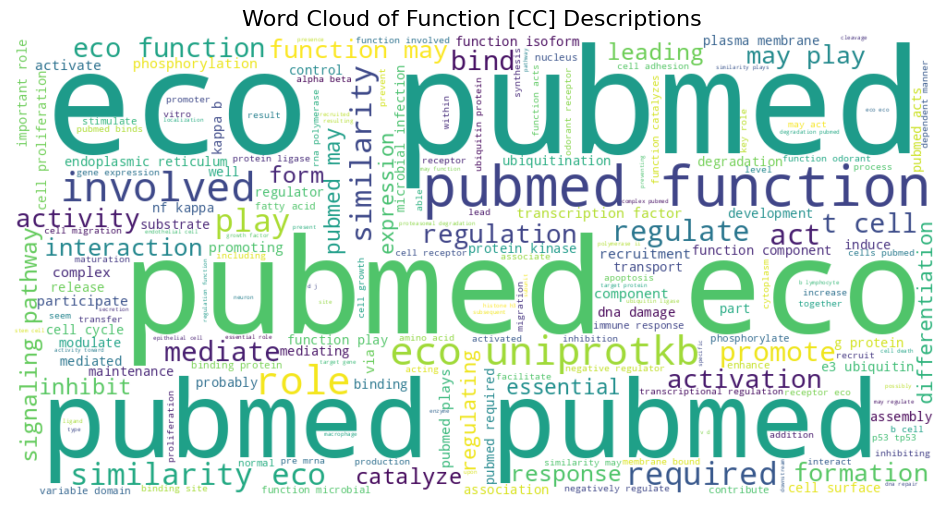

In [6]:
from wordcloud import WordCloud

text = " ".join(df["Function [CC]"].dropna().astype(str).str.lower())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Function [CC] Descriptions", fontsize=16)
plt.show()


> This helps guide the design of keyword-based labeling strategies.

### Frequent Leading Phrases in Function Descriptions

In [7]:
from collections import Counter
import re

def get_leading_words(text, n=10):
    words = text.lower().split()
    return ' '.join(words[:n])

leading_phrases = df["Function [CC]"].dropna().apply(get_leading_words)
Counter(leading_phrases).most_common(30)


[('function: odorant receptor. {eco:0000305}.', 410),
 ('function: may be involved in transcriptional regulation.', 355),
 ('function: in the hair cortex, hair keratin intermediate filaments are',
  102),
 ('function: v region of the variable domain of t cell', 100),
 ('function: v region of the variable domain of immunoglobulin light', 72),
 ('function: may be involved in transcriptional regulation. {eco:0000250}.',
  69),
 ('function: v region of the variable domain of immunoglobulin heavy', 52),
 ('function: potential calcium-dependent cell-adhesion protein. may be involved in the',
  49),
 ('function: the small gtpases rab are key regulators of intracellular', 41),
 ('function: core component of nucleosome. nucleosomes wrap and compact dna',
  39),
 ('function: microtubule inner protein (mip) part of the dynein-decorated doublet',
  37),
 ('function: sequence-specific transcription factor which is part of a developmental',
  35),
 ('function: component of the mediator complex, a co

### Function Labeling via Keyword Matching
The function label dictionary was constructed using a combination of statistical analysis and biological domain knowledge. First, I applied word frequency techniques to identify common patterns in the "Function [CC]" field. Then, I manually grouped related terms into biologically meaningful categories such as "Binding", "Enzyme", "Transport", and "Membrane". This approach ensures interpretability while maintaining alignment with common molecular function annotations found in UniProt records.

In [8]:
df = df.dropna(subset=["Sequence"]).reset_index(drop=True)

# preprocess sequence
def preprocess_sequence(seq):
    seq = seq.replace(" ", "")
    seq = ' '.join(list(seq))
    return f"[CLS] {seq} [SEP]"
df["bert_input"] = df["Sequence"].apply(preprocess_sequence)

# Function keyword dict
keyword_dict = {
    "Binding": [
        "binding", "bind", "binds", "interaction", "ligand", "affinity", "receptor binding"
    ],
    "Enzyme": [
        "enzyme", "catalytic", "kinase", "hydrolase", "oxidoreductase", "atpase",
        "phosphatase", "polymerase", "methyltransferase", "acetyltransferase", "decarboxylase", "dehydrogenase"
    ],
    "Transport": [
        "transporter", "transport", "channel", "pump", "vesicle", "export", "import",
        "uptake", "secretion", "permease", "efflux"
    ],
    "Membrane": [
        "membrane", "transmembrane", "cell membrane", "plasma membrane", "integral",
        "lipid", "bilayer", "endosome", "vesicle", "anchored", "embedded"
    ]
}

# Modular classification function
def categorize_function(text):
    if pd.isna(text):
        return "Other"
    text = text.lower()
    for label, keywords in keyword_dict.items():
        if any(kw in text for kw in keywords):
            return label
    return "Other"

df["label"] = df["Function [CC]"].apply(categorize_function)
df["label_id"] = df["label"].astype("category").cat.codes

print(df["label"].value_counts())

# save new data
df.to_csv("labeled_data.csv", index=False)

label
Other        9626
Binding      5923
Enzyme       2232
Transport    1878
Membrane      762
Name: count, dtype: int64


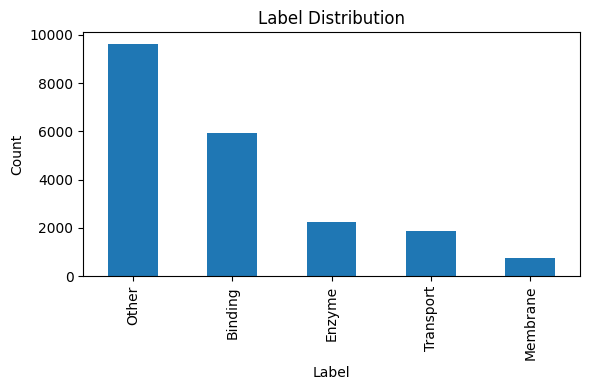

In [9]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar", title="Label Distribution", figsize=(6, 4))
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("label_distribution.png")


###Load the ProtBERT model

In [10]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert")
model = model.to("cuda")
model.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30, 1024, padding_idx=0)
    (position_embeddings): Embedding(40000, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-29): 30 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.0, i

### get embedding

To convert protein sequences into numerical vectors, a pre-trained ProtBERT model was used. The input sequences were first tokenized (up to 512 tokens) by padding and truncation, and then the model was trained on GPU.

Instead of using the [CLS] token representation, **mean pooling** was applied to the last hidden state and weighted with an attention mask to obtain a robust embedding for each sequence.

Finally, the embedding vectors were L2 regularized to ensure scale consistency for the subsequent classification task.

In [11]:
from tqdm import tqdm
import numpy as np

@torch.no_grad()
def extract_embeddings_batch(sequences, batch_size=16):
    embeddings = []
    model.eval()

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i:i + batch_size]

        tokens = tokenizer(batch_seqs,
                           return_tensors="pt",
                           padding=True,
                           truncation=True,
                           max_length=512)

        tokens = {k: v.to("cuda") for k, v in tokens.items()}
        output = model(**tokens)

        # mean pooling
        last_hidden = output.last_hidden_state
        attention_mask = tokens['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_hidden = torch.sum(last_hidden * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        mean_pooled = (sum_hidden / sum_mask).cpu().numpy()

        embeddings.extend(mean_pooled)

    return np.array(embeddings)

# batch
sequences = df["bert_input"].tolist()
embedding_matrix = extract_embeddings_batch(sequences, batch_size=16)

from sklearn.preprocessing import normalize
X_embed = normalize(embedding_matrix, axis=1)

#np.save("protbert_embeddings.npy", embedding_matrix)
np.save("protbert_embeddings.npy", X_embed)

100%|██████████| 1277/1277 [09:21<00:00,  2.27it/s]


success

### Classification Model Training with ProtBERT Embeddings

After obtaining the fixed-length embeddings for each protein sequence using ProtBERT, I trained a multi-layer perceptron (MLP) classifier to predict the function label.

Key steps include:

- **Train/Test Split**: Stratified splitting ensures class balance is maintained in both sets.
- **Class Weights**:I use `compute_class_weight` to address label imbalance and pass weights to the cross-entropy loss function.
- **MLP Training**: The classifier is optimized using Adam, with a learning rate scheduler and dropout layers for regularization.
- **Early Best Model Tracking**: Track and reload the model with the lowest training loss.
- **Evaluation**: Final predictions are evaluated using accuracy, precision, recall, and F1-score. A training loss curve is also plotted for visualization.

This pipeline combines deep protein representation from ProtBERT with a lightweight yet expressive neural classifier to capture non-linear functional relationships.


Epoch 1: Loss = 1.6807
Epoch 2: Loss = 1.5584
Epoch 3: Loss = 1.4858
Epoch 4: Loss = 1.4442
Epoch 5: Loss = 1.4116
Epoch 6: Loss = 1.3971
Epoch 7: Loss = 1.3764
Epoch 8: Loss = 1.3640
Epoch 9: Loss = 1.3534
Epoch 10: Loss = 1.3396
Epoch 11: Loss = 1.3321
Epoch 12: Loss = 1.3161
Epoch 13: Loss = 1.3062
Epoch 14: Loss = 1.2975
Epoch 15: Loss = 1.2862
Epoch 16: Loss = 1.2761
Epoch 17: Loss = 1.2560
Epoch 18: Loss = 1.2560
Epoch 19: Loss = 1.2474
Epoch 20: Loss = 1.2289
Epoch 21: Loss = 1.2274
Epoch 22: Loss = 1.2152
Epoch 23: Loss = 1.2050
Epoch 24: Loss = 1.1938
Epoch 25: Loss = 1.1805
Epoch 26: Loss = 1.1725
Epoch 27: Loss = 1.1670
Epoch 28: Loss = 1.1582
Epoch 29: Loss = 1.1471
Epoch 30: Loss = 1.1374
Epoch 31: Loss = 1.1253
Epoch 32: Loss = 1.1221
Epoch 33: Loss = 1.1171
Epoch 34: Loss = 1.1008
Epoch 35: Loss = 1.0909
Epoch 36: Loss = 1.0853
Epoch 37: Loss = 1.0777
Epoch 38: Loss = 1.0683
Epoch 39: Loss = 1.0573
Epoch 40: Loss = 1.0495
Epoch 41: Loss = 1.0409
Epoch 42: Loss = 1.0319
E

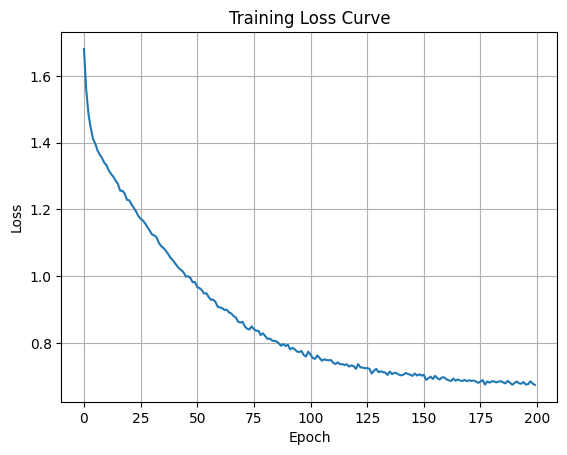

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_def import MLP

# load data
X = np.load("protbert_embeddings.npy")
df = pd.read_csv("labeled_data.csv")
y = df["label_id"].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=20034303)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to("cuda")
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to("cuda")
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to("cuda")
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to("cuda")

# Automatically compute class weights to handle imbalance
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to("cuda")

model = MLP().to("cuda")
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)

# train model
train_losses = []

import copy
best_loss = float("inf")
best_model = None

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())

    # best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

# load best model after training
model.load_state_dict(best_model)

# Evaluate and test
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    print(classification_report(y_test, preds))

# plot loss
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("training_loss_curve.png")

### Model Evaluation and Results

This MLP model is trained on ProtBERT embeddings with 5 output categories. After 200 epochs, the model achieved the following results:

- **Accuracy**: 48%
- **Macro F1 score**: 0.42
- **Weighted F1 score**: 0.50

The training loss continues to decrease, indicating that the model converges steadily. Although the performance varies across categories, the model shows strong predictive power on some categories (e.g., category 3) and has reasonable recall even for underrepresented labels.

In [13]:
torch.save(model.state_dict(), "mlp_model.pth")

Successfully saved !